In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import pickle

# Load the dataset
data = pd.read_csv('weather_dataset_1000.csv')
print("Dataset shape:", data.shape)
print(data.head())

Dataset shape: (1000, 5)
   temperature  humidity  wind_speed  pressure  rainfall
0        27.49     51.11        5.23   1016.82     28.60
1        39.01     72.51        4.94   1019.92     40.27
2        34.64     92.38       18.13   1006.26     38.01
3        31.97     83.93        4.99   1015.62      7.69
4        23.12     88.39        5.44   1014.29      7.46


In [2]:
# EDA: Check for missing values
print("Missing values:")
print(data.isnull().sum())

# Basic statistics
print("\nBasic statistics:")
print(data.describe())

# Data types
print("\nData types:")
print(data.dtypes)

Missing values:
temperature    0
humidity       0
wind_speed     0
pressure       0
rainfall       0
dtype: int64

Basic statistics:
       temperature     humidity   wind_speed     pressure     rainfall
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000
mean     29.805050    70.421110    10.048070  1012.259360    24.705180
std       5.842668    17.531401     5.813503     7.162324    14.340587
min      20.090000    40.190000     0.000000  1000.020000     0.000000
25%      24.715000    54.462500     5.225000  1006.047500    12.247500
50%      29.935000    71.120000    10.010000  1012.105000    24.730000
75%      34.887500    85.630000    15.182500  1018.442500    36.997500
max      39.990000    99.960000    19.960000  1024.990000    49.890000

Data types:
temperature    float64
humidity       float64
wind_speed     float64
pressure       float64
rainfall       float64
dtype: object


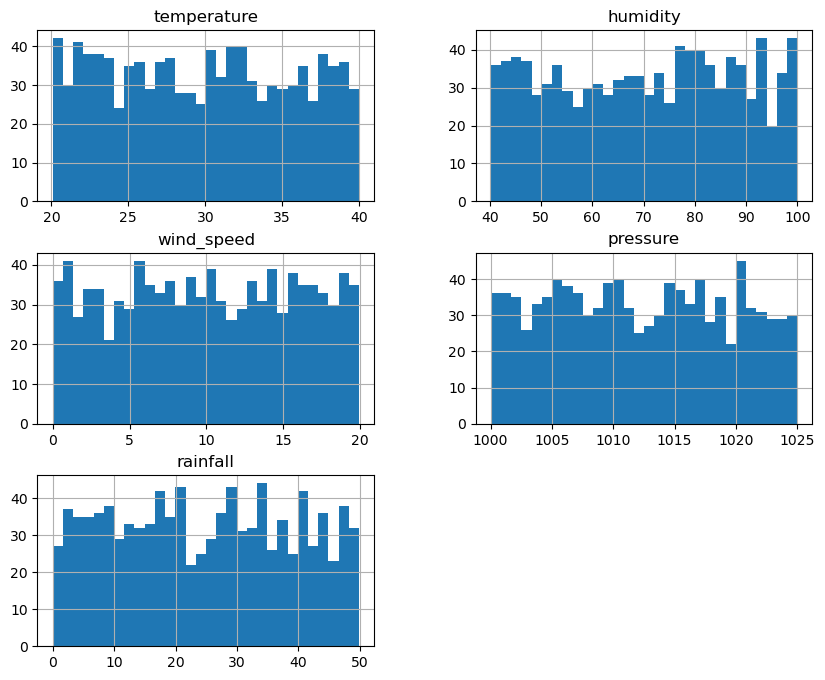

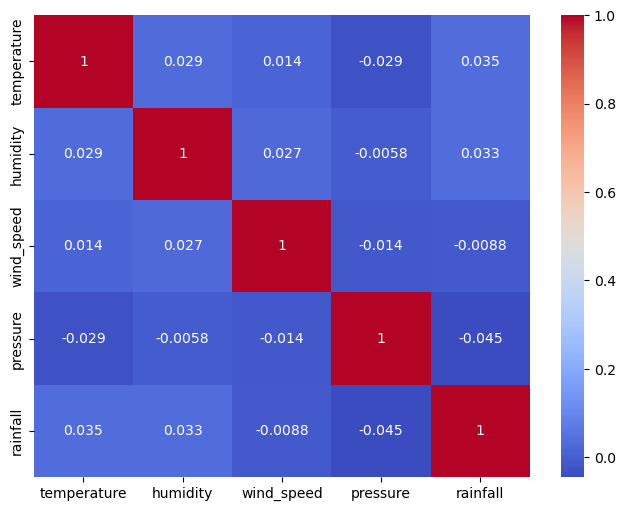

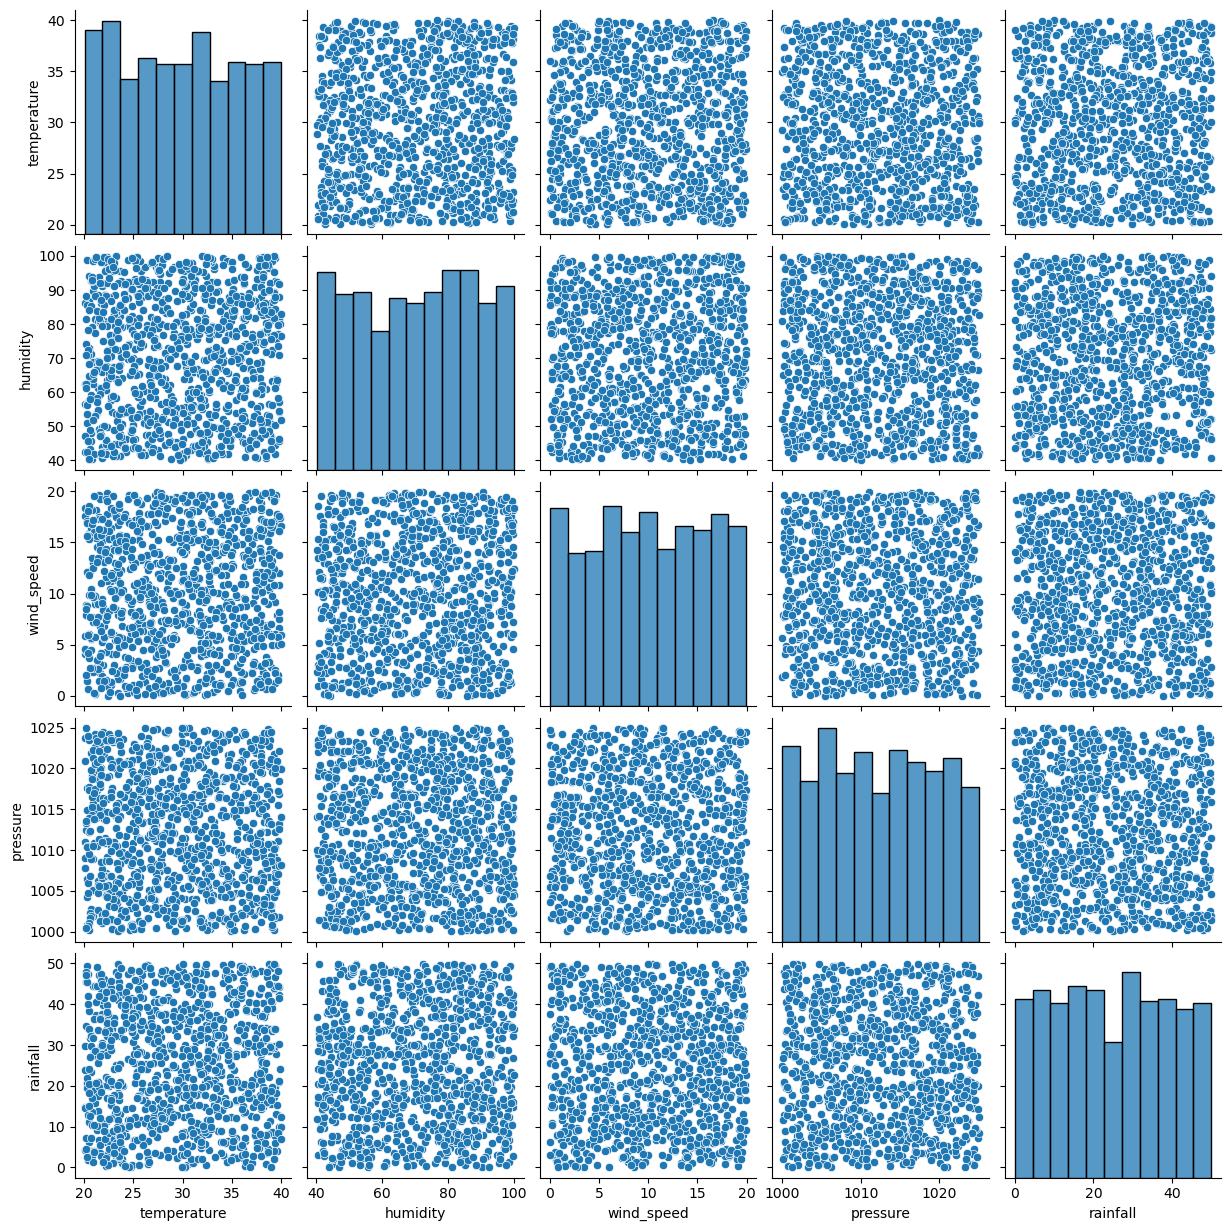

In [3]:
# Histograms for each feature
data.hist(bins=30, figsize=(10, 8))
plt.show()

# Correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

# Pairplot
sns.pairplot(data)
plt.show()

In [4]:
# Data Cleaning: Assuming no missing values, but check for outliers
# For simplicity, if there are outliers, we can remove them, but let's see

# Prepare features and target
X = data.drop('temperature', axis=1)
y = data['temperature']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (800, 4)
Test set shape: (200, 4)


In [5]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression - MSE:", lr_mse, "R2:", lr_r2)

# Model 2: Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest - MSE:", rf_mse, "R2:", rf_r2)

# Model 3: Support Vector Regressor
svr = SVR()
svr.fit(X_train, y_train)
svr_pred = svr.predict(X_test)
svr_mse = mean_squared_error(y_test, svr_pred)
svr_r2 = r2_score(y_test, svr_pred)

print("SVR - MSE:", svr_mse, "R2:", svr_r2)

Linear Regression - MSE: 33.51485969156068 R2: -0.005738508425351396
Random Forest - MSE: 33.81656899995001 R2: -0.014792422796173987
SVR - MSE: 33.690776821749985 R2: -0.011017558785440196


In [6]:
# Compare models
models = ['Linear Regression', 'Random Forest', 'SVR']
mses = [lr_mse, rf_mse, svr_mse]
r2s = [lr_r2, rf_r2, svr_r2]

for model, mse, r2 in zip(models, mses, r2s):
    print(f"{model}: MSE={mse:.2f}, R2={r2:.2f}")

# Select best model based on R2
best_idx = np.argmax(r2s)
best_model_name = models[best_idx]
print(f"\nBest model: {best_model_name}")

# Train best model on full data and save
if best_model_name == 'Linear Regression':
    best_model = LinearRegression()
elif best_model_name == 'Random Forest':
    best_model = RandomForestRegressor(random_state=42)
else:
    best_model = SVR()

best_model.fit(X, y)

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Best model saved as best_model.pkl")

Linear Regression: MSE=33.51, R2=-0.01
Random Forest: MSE=33.82, R2=-0.01
SVR: MSE=33.69, R2=-0.01

Best model: Linear Regression
Best model saved as best_model.pkl
